In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv('Datos/Transformados/df_model_dummies_cluster.csv')
print("Shape inicial:", df.shape)
df.columns

Shape inicial: (52150, 59)


Index(['lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
       'available_units', 'completed_entry_forms_count', 'product_count',
       'reservation_net_value', 'total_adr', 'espera_dias', 'recurrence',
       'tmed', 'prec', 'sol', 'ratio_asistencia', 'bought_products',
       'returning_inhabitant', 'libere_community', 'asset_type_aparthotel',
       'asset_type_apartment', 'asset_type_hostel',
       'business_segment_Business Group',
       'business_segment_Business Individual',
       'business_segment_Leisure Group', 'business_segment_Leisure Individual',
       'business_segment_MICE Group', 'business_segment_MICE Individual',
       'business_segment_Mid Stay', 'business_segment_Travel Group',
       'business_segment_Travel Individual', 'rate_type_Flexible',
       'rate_type_Mid Stay', 'rate_type_Non Refundable',
       'origin_channel_manager', 'origin_direct_channel', 'origin_email',
       'origin_in_person', 'origin_telephone', 'provincia_ARABA/ALAVA',
     

Definir columnas para escalar

In [3]:
cols_num_cluster = [
    'lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
    'available_units', 'completed_entry_forms_count', 'product_count',
    'reservation_net_value', 'total_adr', 'espera_dias',
    'recurrence', 'tmed', 'prec', 'sol', 'ratio_asistencia'
]

cols_bin_cluster = [
    'bought_products', 'returning_inhabitant', 'libere_community'
]

# Nos quedamos solo con las que EXISTAN en el df
cols_finales = [c for c in (cols_num_cluster + cols_bin_cluster) if c in df.columns]

df_clustering = df[cols_finales].copy()

print("Shape clustering:", df_clustering.shape)
print("Columnas usadas:", df_clustering.columns.tolist())

Shape clustering: (52150, 18)
Columnas usadas: ['lead_time', 'lenght_of_stay', 'adult_count', 'child_count', 'available_units', 'completed_entry_forms_count', 'product_count', 'reservation_net_value', 'total_adr', 'espera_dias', 'recurrence', 'tmed', 'prec', 'sol', 'ratio_asistencia', 'bought_products', 'returning_inhabitant', 'libere_community']


MinMaxScaler a numericas

In [4]:
scaler = MinMaxScaler()

df_scaled = df_clustering.copy()
df_scaled[cols_finales] = scaler.fit_transform(df_scaled[cols_finales])

print("Shape tras MinMaxScaler:", df_scaled.shape)

Shape tras MinMaxScaler: (52150, 18)


PCA

In [5]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(df_scaled)

print("Dimensiones originales:", df_scaled.shape[1])
print("Dimensiones tras PCA:", X_pca.shape[1])
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())


Dimensiones originales: 18
Dimensiones tras PCA: 10
Varianza explicada total: 0.967277133475999


Dataframe final con componentes principales

In [6]:
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)
print(X_pca_df.shape)
X_pca_df.head()

(52150, 10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-0.517167,0.353909,0.410168,0.654145,0.345268,0.069141,0.214225,0.154214,-0.177116,0.128033
1,-0.424993,0.021026,1.211335,0.172709,0.201348,0.001678,0.217850,0.138837,-0.069514,0.089714
2,0.736394,0.474115,-0.129388,-0.148104,-0.116117,0.992030,0.072234,0.121234,-0.098592,0.127001
3,0.668127,0.498364,-0.123312,-0.103831,-0.093911,0.651929,0.118075,0.111381,-0.080987,0.134237
4,-0.386465,0.295689,-0.156153,-0.089359,-0.099771,0.057368,0.342755,-0.021250,0.208003,0.159005


### Clustering KMEANS (k 2..10)


KMeans silhouette: {2: 0.1902285937153514, 3: 0.2897598549399693, 4: 0.29708632700090903, 5: 0.2855758607991592, 6: 0.24912145812977118, 7: 0.272962304720798, 8: 0.2530338545792594, 9: 0.2731172851839655, 10: 0.266982567610866}
Best KMeans k: 4 sil: 0.29708632700090903


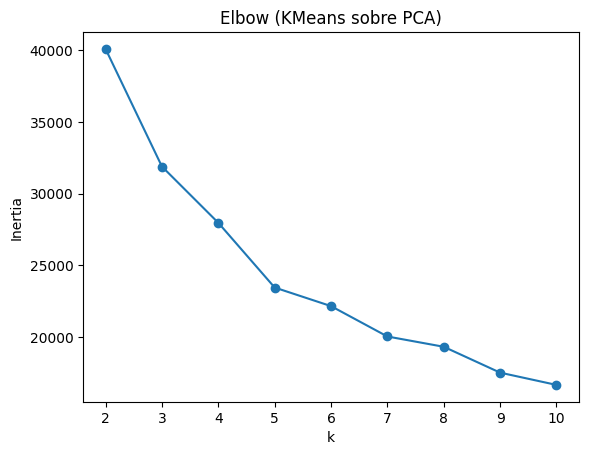

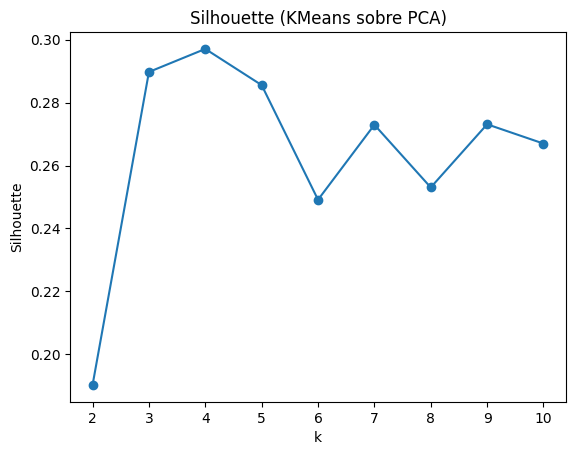

In [7]:
X = X_pca_df.values

Ks = range(2, 11)
kmeans_sil = {}
kmeans_inertia = {}

SAMPLE_SIZE = 10000

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    kmeans_inertia[k] = km.inertia_
    kmeans_sil[k] = silhouette_score(X, labels, sample_size=min(SAMPLE_SIZE, X.shape[0]), random_state=42)

print("KMeans silhouette:", kmeans_sil)
best_k = max(kmeans_sil, key=kmeans_sil.get)
print("Best KMeans k:", best_k, "sil:", kmeans_sil[best_k])

plt.figure()
plt.plot(list(kmeans_inertia.keys()), list(kmeans_inertia.values()), marker="o")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow (KMeans sobre PCA)")
plt.show()

plt.figure()
plt.plot(list(kmeans_sil.keys()), list(kmeans_sil.values()), marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("Silhouette (KMeans sobre PCA)")
plt.show()

### Clustering JERÁRQUICO (Agglomerative) (k 2..10)


Agglomerative silhouette: {2: 0.21183464387980958, 3: 0.2591915927378652, 4: 0.29708632700090903, 5: 0.27523199067966964, 6: 0.28548653079312997, 7: 0.3020661387176915, 8: 0.31861716227326514, 9: 0.2826769721359543, 10: 0.29877942500924926}
Best Agglomerative k: 8 sil: 0.31861716227326514


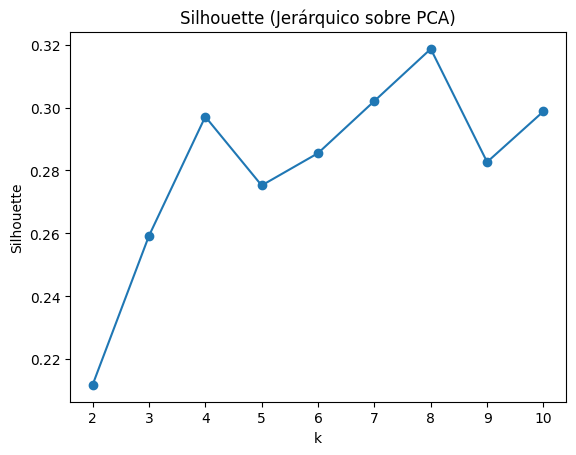

In [8]:

agg_sil = {}
for k in Ks:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")  # ward suele ir bien con euclídea
    labels = agg.fit_predict(X)
    agg_sil[k] = silhouette_score(X, labels, sample_size=min(SAMPLE_SIZE, X.shape[0]), random_state=42)

print("Agglomerative silhouette:", agg_sil)
best_k_agg = max(agg_sil, key=agg_sil.get)
print("Best Agglomerative k:", best_k_agg, "sil:", agg_sil[best_k_agg])

plt.figure()
plt.plot(list(agg_sil.keys()), list(agg_sil.values()), marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("Silhouette (Jerárquico sobre PCA)")
plt.show()

### Clustering DBSCAN (probamos varios eps/min_samples)


In [9]:
eps_list = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_list = [5, 10, 20]

dbscan_results = []

for eps in eps_list:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)

        # clusters válidos (excluye ruido -1)
        unique_labels = set(labels)
        n_noise = np.sum(labels == -1)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

        sil = None
        if n_clusters >= 2:
            # silhouette solo sobre puntos NO ruido
            mask = labels != -1
            sil = silhouette_score(X[mask], labels[mask], sample_size=min(SAMPLE_SIZE, mask.sum()), random_state=42)

        dbscan_results.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil
        })

# Ordenar: primero los que tienen silhouette (no None), y por silhouette desc
dbscan_results_sorted = sorted(
    dbscan_results,
    key=lambda d: (-1 if d["silhouette"] is None else d["silhouette"]),
    reverse=True
)

print("\nTop DBSCAN configs (mejores silhouette):")
for r in dbscan_results_sorted[:10]:
    print(r)


Top DBSCAN configs (mejores silhouette):
{'eps': 0.3, 'min_samples': 20, 'n_clusters': 18, 'n_noise': np.int64(2228), 'silhouette': 0.37219945765676105}
{'eps': 0.5, 'min_samples': 10, 'n_clusters': 16, 'n_noise': np.int64(37), 'silhouette': 0.3670121829244512}
{'eps': 0.4, 'min_samples': 10, 'n_clusters': 16, 'n_noise': np.int64(192), 'silhouette': 0.36607790917612776}
{'eps': 0.6, 'min_samples': 5, 'n_clusters': 16, 'n_noise': np.int64(2), 'silhouette': 0.36577913475485063}
{'eps': 0.6, 'min_samples': 20, 'n_clusters': 16, 'n_noise': np.int64(9), 'silhouette': 0.36518843099145437}
{'eps': 0.5, 'min_samples': 20, 'n_clusters': 16, 'n_noise': np.int64(60), 'silhouette': 0.364808278947073}
{'eps': 0.6, 'min_samples': 10, 'n_clusters': 16, 'n_noise': np.int64(8), 'silhouette': 0.36411615466908603}
{'eps': 0.5, 'min_samples': 5, 'n_clusters': 16, 'n_noise': np.int64(21), 'silhouette': 0.3633994418106942}
{'eps': 0.4, 'min_samples': 5, 'n_clusters': 19, 'n_noise': np.int64(102), 'silhouet